In [22]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from utils import plotFigureGray, plotFigure

### Image Thresholding

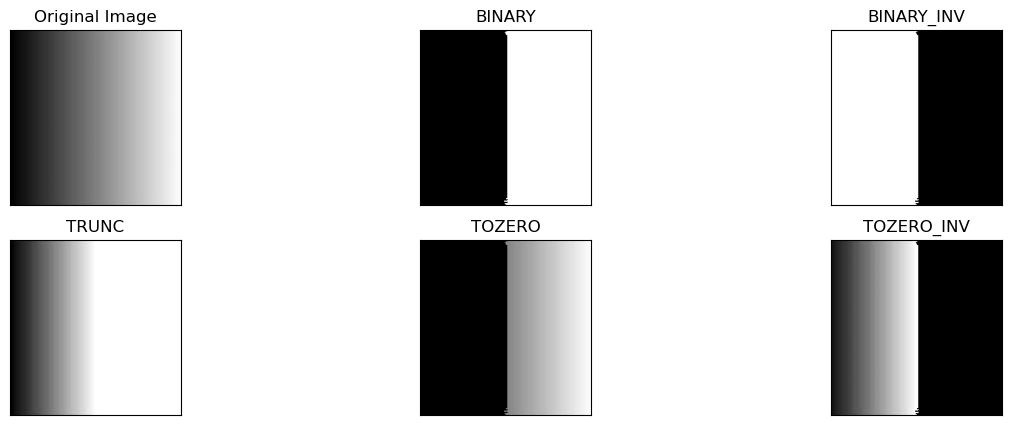

In [23]:
img = cv2.imread('input/gradient.png',0)
ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15, 5))
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

### Adaptive Threshold

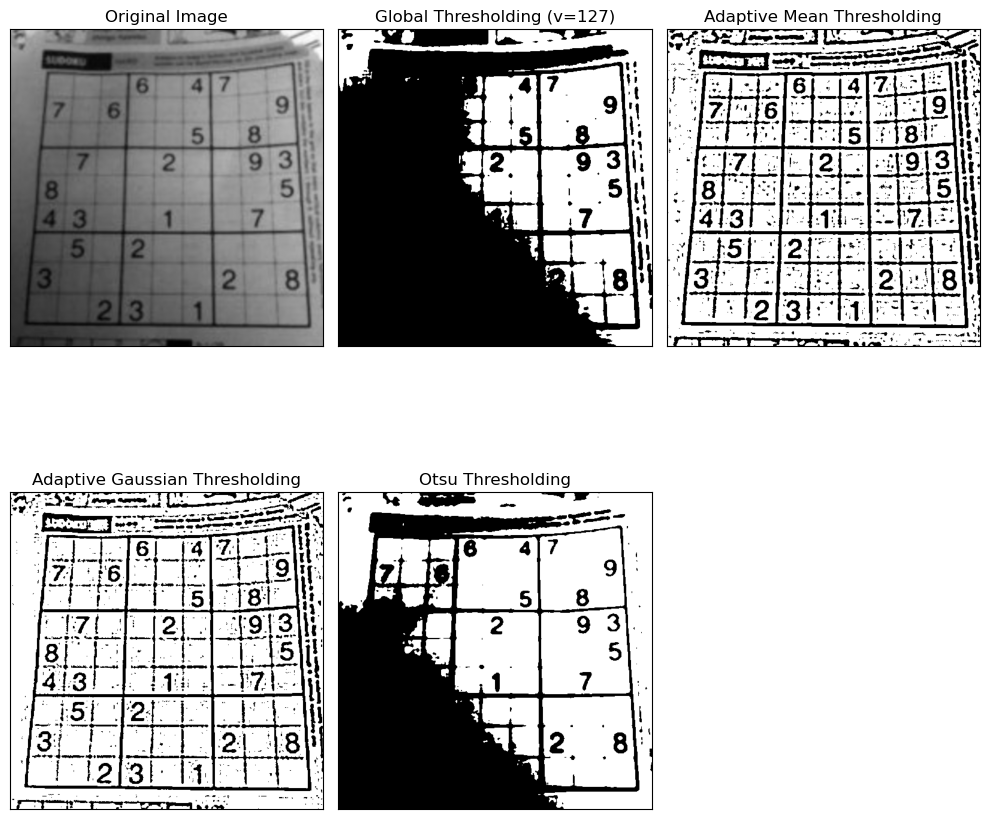

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the image in grayscale
img = cv2.imread('input/histogram.png', 0)

# Optional: smooth the image to reduce noise (already shown)
img = cv2.GaussianBlur(img, (5, 5), 0)

# 1. Global threshold with a fixed value
ret, th1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# 2. Adaptive Mean Thresholding
th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                            cv2.THRESH_BINARY, 11, 2)

# 3. Adaptive Gaussian Thresholding
th3 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                            cv2.THRESH_BINARY, 11, 2)

# 4. Otsu's Thresholding
#    Here threshold=0 is ignored; Otsu finds the best value automatically
ret, th4 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Titles and images for plotting
titles = [
    'Original Image', 
    'Global Thresholding (v=127)',
    'Adaptive Mean Thresholding',
    'Adaptive Gaussian Thresholding',
    'Otsu Thresholding'
]
images = [img, th1, th2, th3, th4]

plt.figure(figsize=(10, 10))

# Show all thresholding results in one figure
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)  # (2 rows, 3 columns) just to fit 5 images
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()


### Morphological Transformations

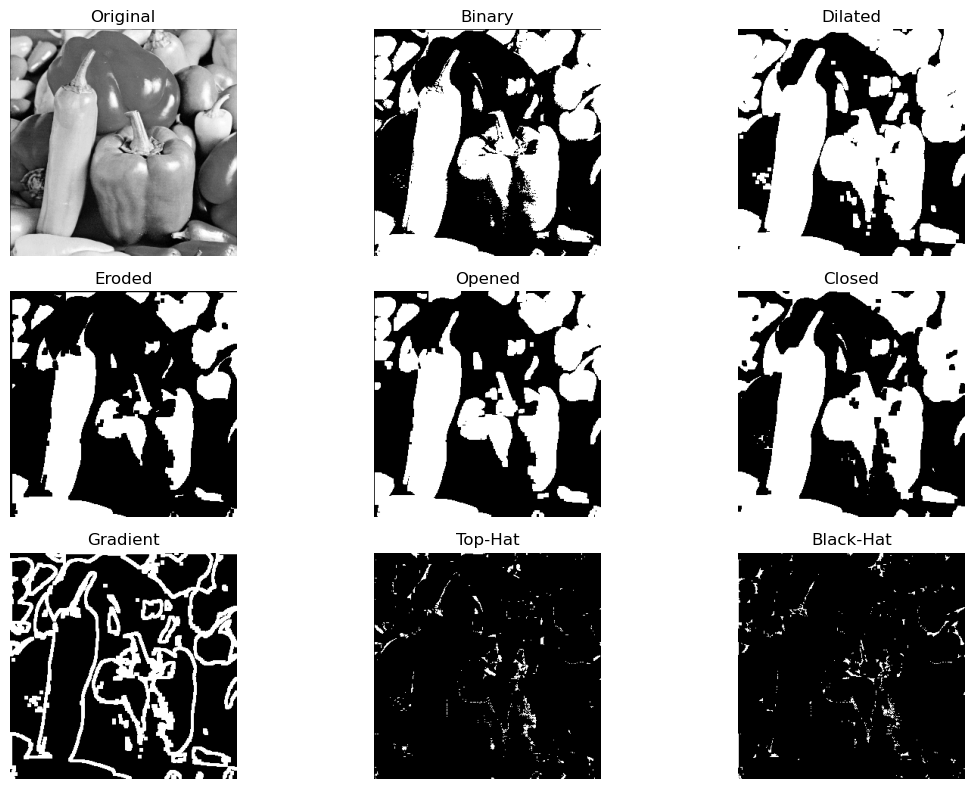

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread("input/j.png", cv2.IMREAD_GRAYSCALE)
image = cv2.imread("input/peppers.png", cv2.IMREAD_GRAYSCALE)


# Resize for consistency
image = cv2.resize(image, (300, 300))

# Convert to binary using thresholding
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Define kernel (structuring element)
kernel = np.ones((5,5), np.uint8)  # 5x5 square kernel

# Apply morphological operations
dilated = cv2.dilate(binary, kernel, iterations=1)
eroded = cv2.erode(binary, kernel, iterations=1)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)  # Opening
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)  # Closing
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)  # Gradient
tophat = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)  # Top-Hat
blackhat = cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)  # Black-Hat

# Display results
titles = ['Original', 'Binary', 'Dilated', 'Eroded', 'Opened', 'Closed', 'Gradient', 'Top-Hat', 'Black-Hat']
images = [image, binary, dilated, eroded, opened, closed, gradient, tophat, blackhat]

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


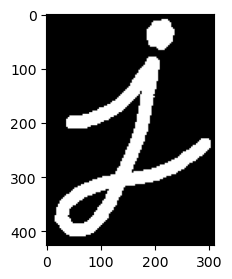

In [7]:
img = cv2.imread('input/j.png',0)
kernel = np.ones((5,5),np.uint8)
plotFigureGray(img)
plt.show()

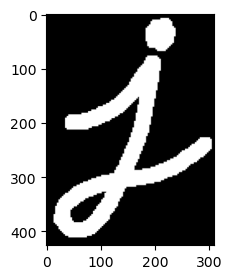

In [8]:
dilate = cv2.dilate(img,kernel,iterations = 1)
plotFigureGray(dilate)
plt.show()

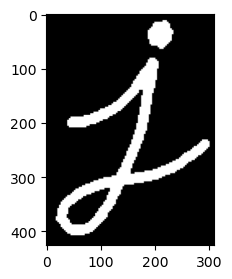

In [9]:

erosion = cv2.erode(img,kernel,iterations = 1)
plotFigureGray(erosion)
plt.show()

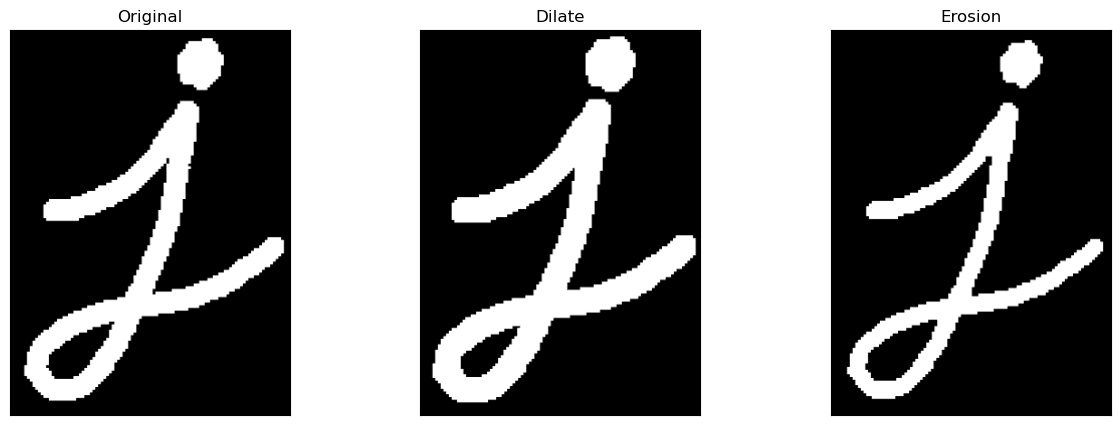

In [10]:
images = [img, dilate, erosion]
titles = ['Original', 'Dilate', 'Erosion']
plt.figure(figsize=(15, 5))

for i in range(3):
    plt.subplot(1,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

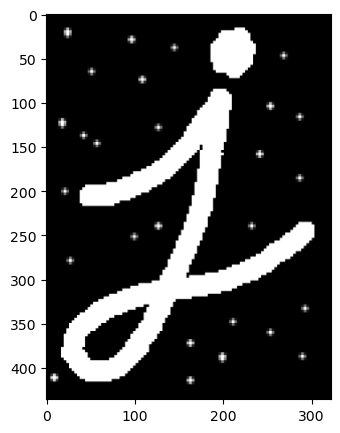

In [11]:
img = cv2.imread('input/j-noise.png',0)
kernel = np.ones((5,5),np.uint8)
plotFigureGray(img,5)
plt.show()

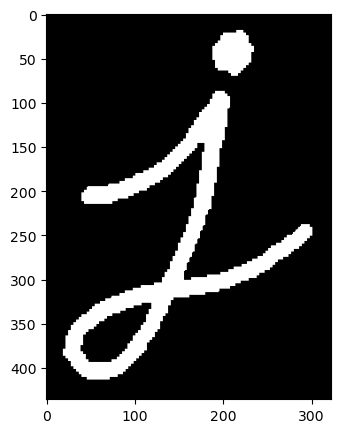

In [12]:
ret,thresh1 = cv2.threshold(img,200,255,cv2.THRESH_BINARY)
erosion = cv2.erode(thresh1,kernel,iterations = 1)
plotFigureGray(erosion,5)
plt.show()

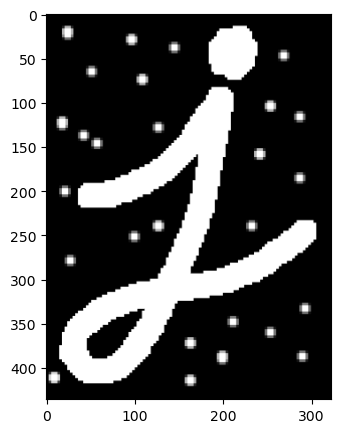

In [13]:
dilate = cv2.dilate(img,kernel,iterations = 1)
plotFigureGray(dilate,5)
plt.show()

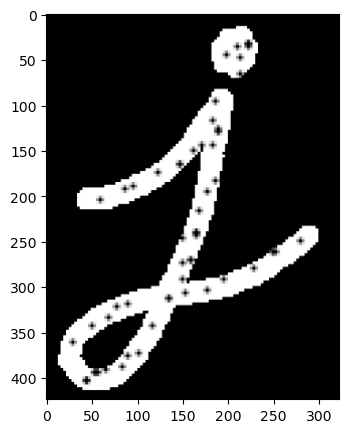

In [14]:
img = cv2.imread('input/j-noise-in.png',0)
kernel = np.ones((5,5),np.uint8)
plotFigureGray(img,5)
plt.show()

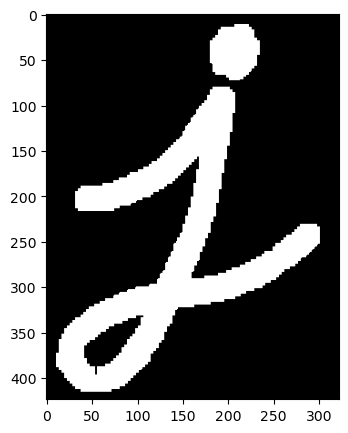

In [15]:
ret,img = cv2.threshold(img,100,255,cv2.THRESH_BINARY)
dilate = cv2.dilate(img,kernel,iterations = 1)
plotFigureGray(dilate,5)
plt.show()

### Opening is just another name of erosion followed by dilation. 
It is useful in removing noise, as we explained above.
Here we use the function, cv2.morphologyEx()

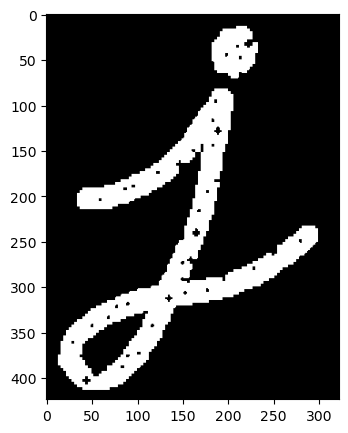

In [16]:
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
plotFigureGray(opening,5)
plt.show()


### Closing is reverse of Opening, Dilation followed by Erosion. 
It is useful in closing small holes inside the foreground
objects, or small black points on the object.

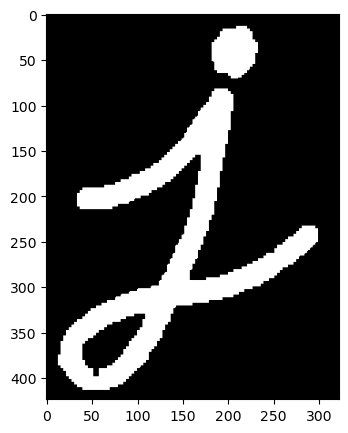

In [17]:
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
plotFigureGray(closing,5)
plt.show()

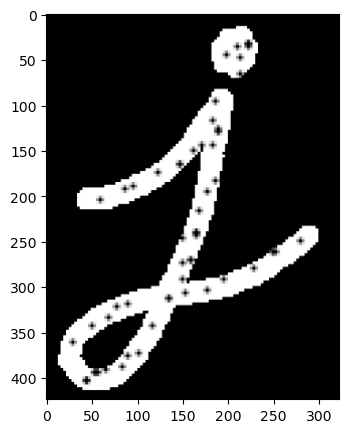

In [18]:
img = cv2.imread('input/j-noise-in.png',0)
kernel = np.ones((5,5),np.uint8)
plotFigureGray(img,5)
plt.show()

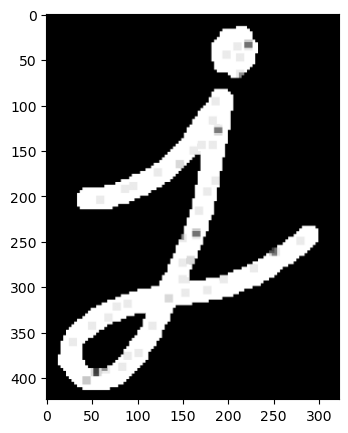

In [19]:
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
plotFigureGray(closing,5)
plt.show()

### Binary Operations

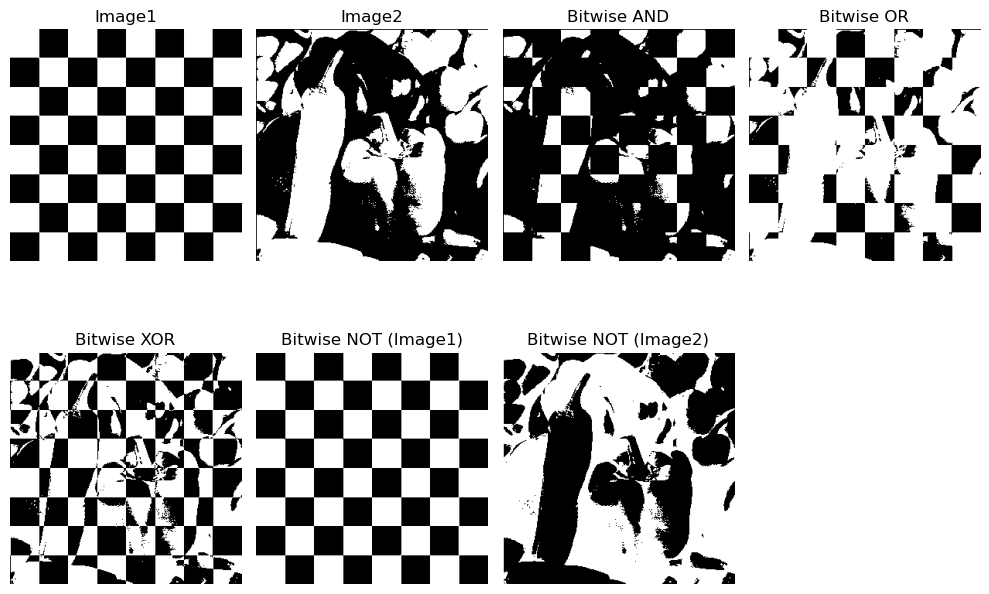

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a grayscale image
image1 = cv2.imread("input/chessboard.png", cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread("input/peppers.png", cv2.IMREAD_GRAYSCALE)

# Resize both images to the same size
image1 = cv2.resize(image1, (300, 300))
image2 = cv2.resize(image2, (300, 300))

# Apply thresholding to convert grayscale images to binary
_, binary1 = cv2.threshold(image1, 127, 255, cv2.THRESH_BINARY)
_, binary2 = cv2.threshold(image2, 127, 255, cv2.THRESH_BINARY)

# Perform binary operations
bitwise_and = cv2.bitwise_and(binary1, binary2)
bitwise_or = cv2.bitwise_or(binary1, binary2)
bitwise_xor = cv2.bitwise_xor(binary1, binary2)
bitwise_not1 = cv2.bitwise_not(binary1)
bitwise_not2 = cv2.bitwise_not(binary2)

# Display results
titles = ['Image1', 'Image2', 'Bitwise AND', 'Bitwise OR', 'Bitwise XOR', 'Bitwise NOT (Image1)', 'Bitwise NOT (Image2)']
images = [binary1, binary2, bitwise_and, bitwise_or, bitwise_xor, bitwise_not1, bitwise_not2]

plt.figure(figsize=(10, 7))
for i in range(7):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()